In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/Users/purikunsrinor/Project/Myself/kaggle practice/credit-risk-model/data/raw/cs-training.csv',index_col=0)
df.shape

(150000, 11)

In [3]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
df['SeriousDlqin2yrs'].value_counts(normalize=True).round(3)

SeriousDlqin2yrs
0    0.933
1    0.067
Name: proportion, dtype: float64

In [5]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [6]:
df['MonthlyIncome_missing'] = df['MonthlyIncome'].isnull().astype(int)
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

df.isnull().sum().sum()

np.int64(0)

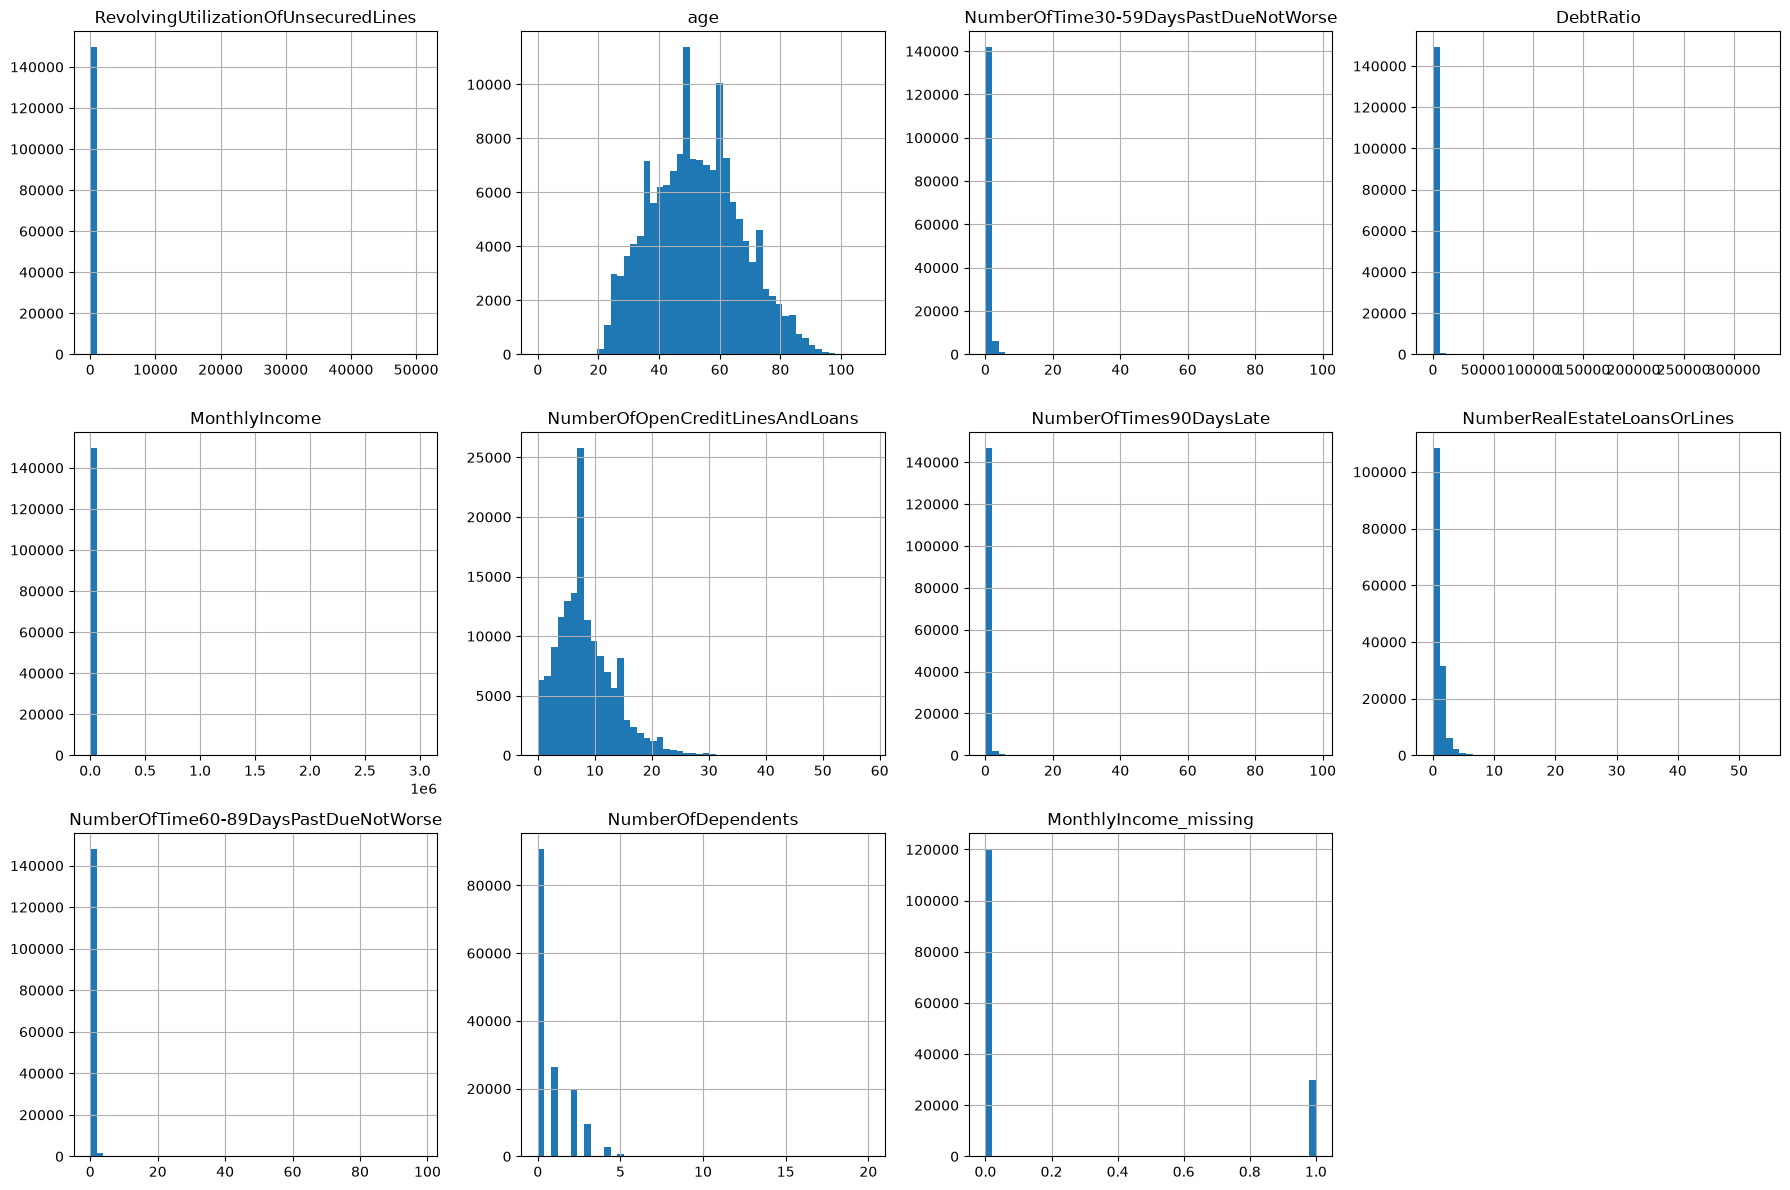

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

features = df.drop('SeriousDlqin2yrs', axis=1).columns

for ax, col in zip(axes.flatten(), features):
    df[col].hist(bins=50, ax=ax)
    ax.set_title(col)

for ax in axes.flatten()[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
# RevolvingUtilization should between 0-1
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)

debt_cap_95 = df['DebtRatio'].quantile(0.95)
df['DebtRatio'] = df['DebtRatio'].clip(upper=debt_cap_95)

print(f"Revolving max: {df['RevolvingUtilizationOfUnsecuredLines'].max()}")
print(f"New DebtRatio max: {df['DebtRatio'].max():.2f}")

Revolving max: 1.0
New DebtRatio max: 2449.00


In [11]:
correlations = df.corr()['SeriousDlqin2yrs'].sort_values(ascending=False)
print(correlations)


SeriousDlqin2yrs                        1.000000
RevolvingUtilizationOfUnsecuredLines    0.278096
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046869
NumberRealEstateLoansOrLines           -0.007038
MonthlyIncome                          -0.017151
MonthlyIncome_missing                  -0.021308
DebtRatio                              -0.022127
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64


In [12]:
df.to_csv("/Users/purikunsrinor/Project/Myself/kaggle practice/credit-risk-model/data/processed/cs-training_cleaned.csv")